# Hands-on — Aula 05: CLIP, BLIP e mini RAG multimodal

As 4 etapas da arquitetura do slide 27, de ponta a ponta, sobre um acervo de
6 imagens geradas no próprio repositório:

| Seção | Tema | Etapa do slide 27 |
|---|---|---|
| 0 | Gerar o acervo de imagens (+ metadados e "OCR simulado") | entrada |
| 1 | CLIP: busca de imagem por texto em PORTUGUÊS | — |
| 2 | Classificação zero-shot | — |
| 3 | BLIP: descrição automática + tradução (Marian da Aula 01) | etapa 1–2 |
| 4 | Mini RAG multimodal com chunk enriquecido e citação | etapas 3–4 |

**Modelos:** `clip-ViT-B-32` (imagens) · `clip-ViT-B-32-multilingual-v1` (texto PT) ·
`blip-image-captioning-base` · `opus-mt-tc-big-en-pt` · `MiniLM` e `Qwen 1.5B` (reuso das aulas 01–04)

In [1]:
import json
from pathlib import Path

import torch
from IPython.display import Image as MostrarImagem
from IPython.display import display
from PIL import Image
from sentence_transformers import SentenceTransformer, util
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()

PASTA = Path("data") / "imagens"
NOMES = ["grafico-barras", "grafico-pizza", "fatura",
         "planta-baixa", "paisagem", "placa-advertencia"]
print("Setup pronto — GPU disponível:", torch.cuda.is_available())

Setup pronto — GPU disponível: True


## Seção 0 — Gerar o acervo *(entrada do pipeline)*

6 imagens sintéticas criadas com Pillow — reprodutíveis e sem direitos de
imagem. Cada uma ganha um `.json` ao lado com metadados e o texto que aparece
nela (**"OCR simulado"** — em produção, um OCR real faria esta etapa).

In [2]:
from PIL import ImageDraw, ImageFont

LARGURA, ALTURA = 512, 384
PASTA.mkdir(parents=True, exist_ok=True)


def fonte(tamanho):
    try:
        return ImageFont.truetype("arialbd.ttf", tamanho)
    except OSError:
        return ImageFont.load_default(tamanho)


def salvar(nome, imagem, tipo, ocr, descricao):
    """Salva a imagem + um sidecar .json com metadados e o texto que ela contém."""
    imagem.save(PASTA / f"{nome}.png")
    meta = {"id": f"img-{nome}", "arquivo": f"{nome}.png", "tipo": tipo,
            "ocr_simulado": ocr, "descricao_curta": descricao}
    (PASTA / f"{nome}.json").write_text(
        json.dumps(meta, ensure_ascii=False, indent=1), encoding="utf-8")
    print(f"  {nome}.png + {nome}.json")


print("Gerando o acervo em data/imagens/ ...")

# 1) Gráfico de barras ------------------------------------------------------
im = Image.new("RGB", (LARGURA, ALTURA), "white")
d = ImageDraw.Draw(im)
d.text((90, 16), "Vendas por Filial (R$ mil)", fill="black", font=fonte(24))
d.line([(60, 330), (470, 330)], fill="black", width=3)   # eixo x
d.line([(60, 60), (60, 330)], fill="black", width=3)     # eixo y
valores = [("Recife", 210, "#2563eb"), ("Salvador", 150, "#16a34a"),
           ("Curitiba", 260, "#dc2626"), ("Manaus", 110, "#f59e0b")]
for i, (cidade, valor, cor) in enumerate(valores):
    x0 = 90 + i * 100
    d.rectangle([x0, 330 - valor, x0 + 60, 330], fill=cor)
    d.text((x0, 340), cidade, fill="black", font=fonte(16))
    d.text((x0 + 10, 310 - valor), str(valor), fill="black", font=fonte(16))
salvar("grafico-barras", im, "grafico",
       "Vendas por Filial (R$ mil) Recife 210 Salvador 150 Curitiba 260 Manaus 110",
       "grafico de barras coloridas comparando vendas de quatro filiais")

# 2) Gráfico de pizza -------------------------------------------------------
im = Image.new("RGB", (LARGURA, ALTURA), "white")
d = ImageDraw.Draw(im)
d.text((110, 16), "Chamados por Categoria", fill="black", font=fonte(24))
fatias = [(0, 150, "#2563eb"), (150, 240, "#16a34a"),
          (240, 310, "#f59e0b"), (310, 360, "#dc2626")]
for ini, fim, cor in fatias:
    d.pieslice([120, 70, 390, 340], ini, fim, fill=cor, outline="white", width=3)
d.text((400, 120), "Acesso 42%", fill="#2563eb", font=fonte(15))
d.text((400, 160), "Erro 25%", fill="#16a34a", font=fonte(15))
d.text((400, 200), "Duvida 19%", fill="#f59e0b", font=fonte(15))
d.text((400, 240), "Outros 14%", fill="#dc2626", font=fonte(15))
salvar("grafico-pizza", im, "grafico",
       "Chamados por Categoria Acesso 42% Erro 25% Duvida 19% Outros 14%",
       "grafico de pizza com a distribuicao de chamados por categoria")

# 3) Fatura (documento com texto) ------------------------------------------
im = Image.new("RGB", (LARGURA, ALTURA), "#f8f8f6")
d = ImageDraw.Draw(im)
d.rectangle([20, 20, 492, 364], outline="#94a3b8", width=2)
linhas = [
    ("FATURA Nº 2026-117", 28, 40),
    ("Innovatech Soluções Ltda.", 18, 90),
    ("Cliente: Padaria Estrela do Norte ME", 16, 130),
    ("Emissão: 12/08/2026   Vencimento: 15/09/2026", 16, 165),
    ("Serviço: Licença InnovaAnalytics (12 meses)", 16, 200),
    ("Subtotal: R$ 1.675,00", 16, 245),
    ("Impostos: R$ 167,50", 16, 280),
    ("TOTAL A PAGAR: R$ 1.842,50", 22, 315),
]
for texto, tamanho, y in linhas:
    d.text((44, y), texto, fill="#111827", font=fonte(tamanho))
salvar("fatura", im, "documento",
       "FATURA Nº 2026-117 Innovatech Soluções Cliente Padaria Estrela do Norte "
       "Emissão 12/08/2026 Vencimento 15/09/2026 Licença InnovaAnalytics "
       "Subtotal R$ 1.675,00 Impostos R$ 167,50 TOTAL A PAGAR R$ 1.842,50",
       "documento de fatura com numero, datas e valor total")

# 4) Planta baixa -----------------------------------------------------------
im = Image.new("RGB", (LARGURA, ALTURA), "white")
d = ImageDraw.Draw(im)
d.text((150, 12), "Planta - Escritorio 3º andar", fill="black", font=fonte(20))
d.rectangle([40, 50, 470, 350], outline="black", width=4)
d.line([(250, 50), (250, 350)], fill="black", width=3)
d.line([(250, 200), (470, 200)], fill="black", width=3)
d.rectangle([40, 180, 52, 230], fill="white", outline="black", width=2)  # porta
d.text((80, 180), "Sala de\nReuniao", fill="black", font=fonte(18))
d.text((300, 100), "Estacoes de\nTrabalho", fill="black", font=fonte(18))
d.text((300, 260), "Copa", fill="black", font=fonte(18))
salvar("planta-baixa", im, "diagrama",
       "Planta Escritorio 3 andar Sala de Reuniao Estacoes de Trabalho Copa",
       "planta baixa simplificada de um escritorio com tres ambientes")

# 5) Paisagem ---------------------------------------------------------------
im = Image.new("RGB", (LARGURA, ALTURA), "white")
d = ImageDraw.Draw(im)
for y in range(240):  # céu em degradê
    azul = int(235 - y * 0.45)
    d.line([(0, y), (LARGURA, y)], fill=(120, 170, azul))
d.ellipse([390, 40, 460, 110], fill="#fde047", outline="#facc15")  # sol
d.polygon([(0, 240), (150, 110), (300, 240)], fill="#64748b")      # montanha 1
d.polygon([(180, 240), (350, 90), (512, 240)], fill="#475569")     # montanha 2
d.rectangle([0, 240, 512, 384], fill="#4d7c0f")                    # campo
salvar("paisagem", im, "foto", "",
       "paisagem com montanhas, sol e campo verde")

# 6) Placa de advertência ---------------------------------------------------
im = Image.new("RGB", (LARGURA, ALTURA), "#e5e7eb")
d = ImageDraw.Draw(im)
d.polygon([(256, 40), (60, 300), (452, 300)], fill="#facc15", outline="black", width=6)
d.text((236, 120), "!", fill="black", font=fonte(110))
d.text((150, 320), "CUIDADO: PISO MOLHADO", fill="black", font=fonte(20))
salvar("placa-advertencia", im, "sinalizacao",
       "CUIDADO PISO MOLHADO",
       "placa triangular amarela de advertencia com ponto de exclamacao")

# Contact-sheet (visão geral 3x2) ------------------------------------------
folha = Image.new("RGB", (LARGURA * 3 + 40, ALTURA * 2 + 30), "white")
for i, nome in enumerate(NOMES):
    img = Image.open(PASTA / f"{nome}.png")
    x, y = (i % 3) * (LARGURA + 10) + 10, (i // 3) * (ALTURA + 10) + 10
    folha.paste(img, (x, y))
folha.save(PASTA / "visao-geral.png")
print("  visao-geral.png (contact-sheet 3x2)")

Gerando o acervo em data/imagens/ ...
  grafico-barras.png + grafico-barras.json
  grafico-pizza.png + grafico-pizza.json
  fatura.png + fatura.json
  planta-baixa.png + planta-baixa.json
  paisagem.png + paisagem.json
  placa-advertencia.png + placa-advertencia.json
  visao-geral.png (contact-sheet 3x2)


Metadados da fatura (o sidecar .json que viaja com a imagem):
{
 "id": "img-fatura",
 "arquivo": "fatura.png",
 "tipo": "documento",
 "ocr_simulado": "FATURA Nº 2026-117 Innovatech Soluções Cliente Padaria Estrela do Norte Emissão 12/08/2026 Vencimento 15/09/2026 Licença InnovaAnalytics Subtotal R$ 1.675,00 Impostos R$ 167,50 TOTAL A PAGAR R$ 1.842,50",
 "descricao_curta": "documento de fatura com numero, datas e valor total"
}


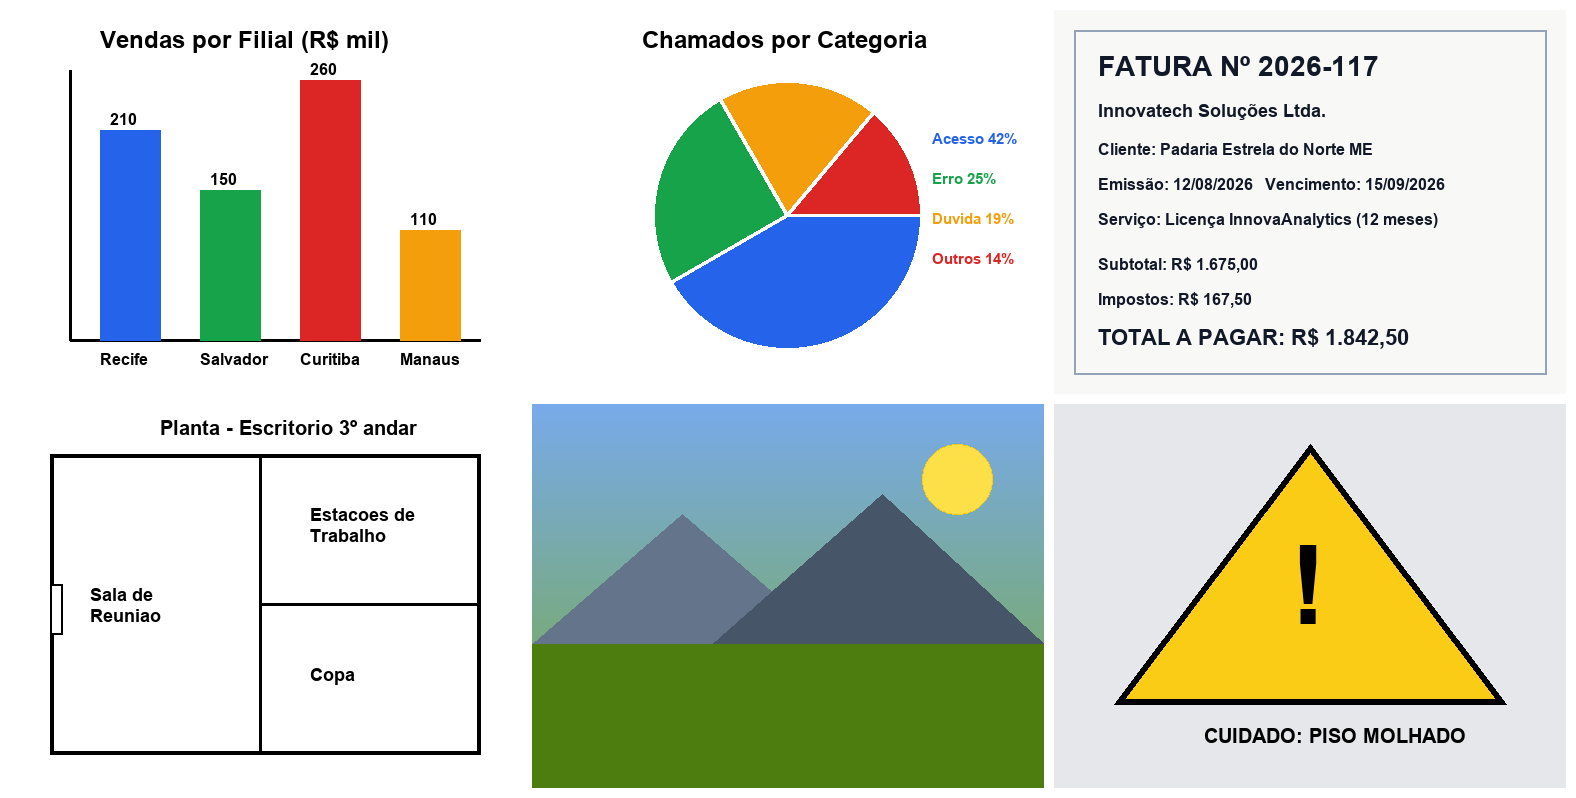

In [3]:
meta_exemplo = json.loads((PASTA / "fatura.json").read_text(encoding="utf-8"))
print("Metadados da fatura (o sidecar .json que viaja com a imagem):")
print(json.dumps(meta_exemplo, ensure_ascii=False, indent=1))
display(MostrarImagem(filename=str(PASTA / "visao-geral.png"), width=900))

## Seção 1 — CLIP: busca de imagem por texto em português *(slides 7–9)*

Duas redes, um espaço vetorial COMPARTILHADO: `clip-ViT-B-32` embute as
IMAGENS; `clip-ViT-B-32-multilingual-v1` embute o TEXTO (aceita português).
A consulta encontra a imagem certa SEM nenhum rótulo manual.

In [4]:
enc_imagem = SentenceTransformer("sentence-transformers/clip-ViT-B-32")
enc_texto = SentenceTransformer("sentence-transformers/clip-ViT-B-32-multilingual-v1")

imagens = [Image.open(PASTA / f"{n}.png") for n in NOMES]
emb_imagens = enc_imagem.encode(imagens, convert_to_tensor=True,
                                normalize_embeddings=True)
print(f"matriz: {tuple(emb_imagens.shape)} — imagem virou vetor, como texto vira")

CONSULTAS = [
    "um gráfico de pizza com fatias coloridas",
    "um documento de cobrança com valor a pagar",
    "montanhas com sol e um campo verde",
    "um aviso de segurança amarelo",
]

for consulta in CONSULTAS:
    vetor = enc_texto.encode(consulta, convert_to_tensor=True, normalize_embeddings=True)
    similaridades = util.cos_sim(vetor, emb_imagens)[0]
    ranking = sorted(zip(NOMES, similaridades.tolist()), key=lambda par: -par[1])
    print("=" * 70)
    print(f'CONSULTA (PT): "{consulta}"')
    for nome, sim in ranking[:3]:
        print(f"  {sim:.3f}  {nome}")

print("\nTexto em português encontrando imagens: o aprendizado contrastivo do")
print("CLIP aproximou legendas e imagens no MESMO espaço vetorial.")

matriz: (6, 512) — imagem virou vetor, como texto vira
CONSULTA (PT): "um gráfico de pizza com fatias coloridas"
  0.243  grafico-pizza
  0.215  grafico-barras
  0.210  paisagem
CONSULTA (PT): "um documento de cobrança com valor a pagar"
  0.231  fatura
  0.226  paisagem
  0.223  planta-baixa
CONSULTA (PT): "montanhas com sol e um campo verde"
  0.310  paisagem
  0.205  planta-baixa
  0.205  grafico-barras
CONSULTA (PT): "um aviso de segurança amarelo"
  0.293  placa-advertencia
  0.212  paisagem
  0.204  planta-baixa

Texto em português encontrando imagens: o aprendizado contrastivo do
CLIP aproximou legendas e imagens no MESMO espaço vetorial.


## Seção 2 — Classificação zero-shot *(slide 8)*

Sem treinar NADA: os rótulos são frases em português, e cada imagem é
classificada pela similaridade com cada rótulo (softmax das similaridades).
**Observe onde confunde** — estilos parecidos, texto dentro da imagem,
desenho sintético: limitações reais (slide 22).

In [5]:
ROTULOS = [
    "um gráfico de barras",
    "um gráfico de pizza",
    "uma fatura com valores",
    "a planta baixa de um escritório",
    "uma paisagem com montanhas",
    "uma placa de advertência",
]

emb_rotulos = enc_texto.encode(ROTULOS, convert_to_tensor=True, normalize_embeddings=True)
logits = util.cos_sim(emb_imagens, emb_rotulos) * 100
probabilidades = torch.softmax(logits, dim=1)

print("PROBABILIDADE POR RÓTULO (cada linha soma 100%):\n")
print(" " * 18 + "".join(f"{r.split()[1][:7]:>9s}" for r in ROTULOS))
acertos = 0
for i, nome in enumerate(NOMES):
    linha = "".join(f"{100 * float(p):8.1f}%" for p in probabilidades[i])
    print(f"{nome:18s}{linha}")
    acertos += int(torch.argmax(probabilidades[i])) == i

print(f"\nACERTOS (diagonal): {acertos}/6 — sem nenhum exemplo de treino.")

PROBABILIDADE POR RÓTULO (cada linha soma 100%):

                    gráfico  gráfico   fatura   planta  paisage    placa
grafico-barras        88.0%     8.3%     3.2%     0.3%     0.1%     0.1%
grafico-pizza         85.6%    13.0%     1.2%     0.3%     0.0%     0.0%
fatura                24.1%    26.2%    31.4%     3.4%     1.0%    14.0%
planta-baixa          82.2%     5.8%     2.9%     7.1%     0.4%     1.6%
paisagem               0.2%     0.0%     0.1%     0.0%    99.6%     0.0%
placa-advertencia      0.3%     0.1%     0.1%     0.1%     0.0%    99.3%

ACERTOS (diagonal): 4/6 — sem nenhum exemplo de treino.


## Seção 3 — BLIP: descrição automática + tradução *(slide 27, etapa 1)*

O BLIP gera legendas em inglês; o Marian (o mesmo da Aula 01!) traduz para
português. **Observe:** legenda ótima na paisagem, LOOP de repetição na pizza
(callback da `repetition_penalty` da Aula 03) e legendas vagas nos documentos —
é por isso que o chunk enriquecido precisa de OCR + metadados.

In [6]:
from transformers import (BlipForConditionalGeneration, BlipProcessor,
                          MarianMTModel, MarianTokenizer)

dispositivo = "cuda" if torch.cuda.is_available() else "cpu"

processador = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base").to(dispositivo)
tok_m = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-tc-big-en-pt")
marian = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-tc-big-en-pt").to(dispositivo)


def legendar(imagem):
    entradas = processador(imagem, return_tensors="pt").to(dispositivo)
    with torch.no_grad():
        saida = blip.generate(**entradas, max_new_tokens=30)
    return processador.decode(saida[0], skip_special_tokens=True)


def traduzir(texto_en):
    lote = tok_m(f">>por<< {texto_en}", return_tensors="pt").to(dispositivo)
    with torch.no_grad():
        saida = marian.generate(**lote, max_new_tokens=60)
    return tok_m.decode(saida[0], skip_special_tokens=True)


legendas = {}
for nome in NOMES:
    legenda_en = legendar(Image.open(PASTA / f"{nome}.png").convert("RGB"))
    legendas[nome] = traduzir(legenda_en)
    print(f"{nome}")
    print(f"  BLIP (EN):   {legenda_en}")
    print(f"  Marian (PT): {legendas[nome]}")
    print("-" * 70)

(PASTA / "legendas.json").write_text(
    json.dumps(legendas, ensure_ascii=False, indent=1), encoding="utf-8")
print("Legendas salvas — a Seção 4 as usa no chunk enriquecido.")

grafico-barras
  BLIP (EN):   a bar graph with the number of the different parts of the plant
  Marian (PT): um gráfico de barras com o número das diferentes partes da planta
----------------------------------------------------------------------


grafico-pizza
  BLIP (EN):   a pie chart with the percentage of the percentage of the percentage of the percentage of the percentage of the percentage
  Marian (PT): um gráfico de pizza com a percentagem da percentagem da percentagem da percentagem da percentagem da percentagem da percentagem
----------------------------------------------------------------------


fatura
  BLIP (EN):   a white background with the words ' fatra ' and ' fatra '
  Marian (PT): um fundo branco com as palavras 'fatra' e 'fatra'
----------------------------------------------------------------------
planta-baixa
  BLIP (EN):   plano de esto
  Marian (PT): plano de esto
----------------------------------------------------------------------


paisagem
  BLIP (EN):   a mountain with a sun in the sky
  Marian (PT): uma montanha com um sol no céu
----------------------------------------------------------------------


placa-advertencia
  BLIP (EN):   a yellow triangle with the words cud - psi mold
  Marian (PT): um triângulo amarelo com as palavras cud - psi mold
----------------------------------------------------------------------
Legendas salvas — a Seção 4 as usa no chunk enriquecido.


## Seção 4 — Mini RAG multimodal *(slide 27, etapas 3–4; chunk enriquecido do slide 19)*

Para cada imagem, um **chunk enriquecido**: descrição do BLIP + texto do OCR
simulado + metadados. A pergunta em PT recupera o chunk certo, e o Qwen
responde citando `[img-N]`.

**Momento avaliação (slide 20):** na pergunta do gráfico, confira a resposta
contra o gabarito — recuperar a evidência certa NÃO garante ler o número certo.

In [7]:
chunks = []
for nome in NOMES:
    meta = json.loads((PASTA / f"{nome}.json").read_text(encoding="utf-8"))
    texto = (f"descrição: {legendas[nome]}. "
             f"conteúdo: {meta['descricao_curta']}. "
             f"texto na imagem: {meta['ocr_simulado'] or '(sem texto)'}")
    chunks.append({"id": meta["id"], "tipo": meta["tipo"], "texto": texto})

exemplo = next(c for c in chunks if c["id"] == "img-fatura")
print("CHUNK ENRIQUECIDO da fatura (descrição + OCR + metadados juntos):")
print(f"  id={exemplo['id']} tipo={exemplo['tipo']}")
print(f'  texto="{exemplo["texto"][:200]}..."')

emb = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
vetores = emb.encode([c["texto"] for c in chunks], convert_to_tensor=True,
                     normalize_embeddings=True)
print("\nChunks indexados (mesmo modelo de embeddings da Aula 02).")

CHUNK ENRIQUECIDO da fatura (descrição + OCR + metadados juntos):
  id=img-fatura tipo=documento
  texto="descrição: um fundo branco com as palavras 'fatra' e 'fatra'. conteúdo: documento de fatura com numero, datas e valor total. texto na imagem: FATURA Nº 2026-117 Innovatech Soluções Cliente Padaria Est..."



Chunks indexados (mesmo modelo de embeddings da Aula 02).


In [8]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tok = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")
llm = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct",
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None)

SISTEMA = """Você responde com base nas evidências de um acervo de imagens.
Cada evidência tem um id como [img-fatura]. Responda de forma curta e
termine SEMPRE com a linha: Fonte: [id]
Se as evidências não contiverem a resposta, diga que não encontrou."""


def responder(pergunta):
    vetor = emb.encode(pergunta, convert_to_tensor=True, normalize_embeddings=True)
    ranking = util.cos_sim(vetor, vetores)[0].argsort(descending=True)
    top = [chunks[int(i)] for i in ranking[:2]]
    print("-" * 70)
    print(f'PERGUNTA: "{pergunta}"')
    for c in top:
        print(f"  evidência recuperada: [{c['id']}] (tipo {c['tipo']})")
    blocos = "\n\n".join(f"[{c['id']}]\n{c['texto']}" for c in top)
    msgs = [{"role": "system", "content": SISTEMA},
            {"role": "user", "content": f"Evidências:\n\n{blocos}\n\nPergunta: {pergunta}"}]
    entrada = tok.apply_chat_template(msgs, add_generation_prompt=True,
                                      return_dict=True, return_tensors="pt").to(llm.device)
    with torch.no_grad():
        saida = llm.generate(**entrada, max_new_tokens=120, do_sample=False,
                             pad_token_id=tok.eos_token_id)
    n = entrada["input_ids"].shape[1]
    print("RESPOSTA:", tok.decode(saida[0][n:], skip_special_tokens=True).strip())


responder("Qual é o número da fatura e qual o valor total a pagar?")
responder("Qual filial teve o maior valor de vendas no gráfico?")
responder("Existe algum aviso de segurança no acervo? O que ele diz?")

print("=" * 70)
print("MOMENTO AVALIAÇÃO (slide 20): o maior valor do gráfico é CURITIBA")
print("(R$ 260 mil). O modelo acertou? Comparação numérica é fraqueza conhecida")
print("de modelos pequenos — por isso avaliamos recuperação e geração")
print("SEPARADAMENTE, com grounding visual (slides 20-21).")

----------------------------------------------------------------------
PERGUNTA: "Qual é o número da fatura e qual o valor total a pagar?"
  evidência recuperada: [img-fatura] (tipo documento)
  evidência recuperada: [img-grafico-barras] (tipo grafico)


RESPOSTA: Fonte: [img-fatura]

Número da fatura: 2026-117
Valor total a pagar: R$ 1.842,50
----------------------------------------------------------------------
PERGUNTA: "Qual filial teve o maior valor de vendas no gráfico?"
  evidência recuperada: [img-grafico-barras] (tipo grafico)
  evidência recuperada: [img-fatura] (tipo documento)


RESPOSTA: Fonte: [img-grafico-barras]

A filial que teve o maior valor de vendas no gráfico é Recife, com R$ 210 mil em vendas.
----------------------------------------------------------------------
PERGUNTA: "Existe algum aviso de segurança no acervo? O que ele diz?"
  evidência recuperada: [img-placa-advertencia] (tipo sinalizacao)
  evidência recuperada: [img-paisagem] (tipo foto)


RESPOSTA: Fonte: [img-placa-advertencia]

Existe um aviso de segurança no acervo. Ele diz "CUIDADO PISO MOLHADO".
MOMENTO AVALIAÇÃO (slide 20): o maior valor do gráfico é CURITIBA
(R$ 260 mil). O modelo acertou? Comparação numérica é fraqueza conhecida
de modelos pequenos — por isso avaliamos recuperação e geração
SEPARADAMENTE, com grounding visual (slides 20-21).
